# Konux Case Study – Preliminary Train Passage Analysis

This notebook implements an end‑to‑end pipeline for the provided vertical acceleration traces:

1. Load binary acceleration files (float32, unit **g**) sampled at **2 kHz**  
2. Preprocess (baseline removal + bandpass filtering)  
3. Segment the train passage (moving RMS + robust threshold)  
4. Extract time & frequency domain features  
5. Cluster passages (unsupervised train type grouping) and compute a speed **proxy**

> Note: The case study states that the data is insufficient to uniquely determine train type and speed.  
> The focus is therefore on a sound methodology and interpretable results.


In [1]:
import os, glob, re
import numpy as np
import pandas as pd
import scipy.signal as sig
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

FS = 2000.0  # Hz
DATA_DIR = "/home/mamunds/job/pyspark/konux/data"  # folder containing the .bin files


## 1) I/O helpers

In [2]:
def read_trace(path: str) -> np.ndarray:
    # Binary float32 values representing acceleration in g
    return np.fromfile(path, dtype=np.float32)

def parse_meta(path: str) -> dict:
    base = os.path.basename(path)
    m = re.match(r"(\d{8})_(\d{6})_(\d+?)_(\d+?)_channel(\d+)", base)
    if not m:
        return dict(date=None,time=None,sensor_id=None,deployment_id=None,channel=None,file=base)
    ymd,hms,sid,did,ch = m.groups()
    return dict(date=ymd,time=hms,sensor_id=int(sid),deployment_id=int(did),channel=int(ch),file=base)


## 2) Preprocessing

In [3]:
def preprocess(x: np.ndarray, fs: float = FS) -> np.ndarray:
    # Robust baseline removal
    x = x.astype(np.float64)
    x = x - np.median(x)

    # Bandpass: keep typical train/track vibration energy (tunable)
    sos = sig.butter(4, [5, 400], btype="bandpass", fs=fs, output="sos")
    return sig.sosfiltfilt(sos, x)


## 3) Segment the train passage

In [4]:
def moving_rms(x: np.ndarray, win: int) -> np.ndarray:
    kernel = np.ones(win) / win
    return np.sqrt(sig.convolve(x**2, kernel, mode="same"))

def segment_passage(x: np.ndarray, fs: float = FS, win_s: float = 0.1,
                    z: float = 6.0, pad_s: float = 0.5):
    """
    Segment the main train passage using RMS envelope + robust threshold.
    Returns: segment, (start,end), rms_envelope, threshold
    """
    win = max(1, int(win_s * fs))
    rms = moving_rms(x, win)

    med = np.median(rms)
    mad = np.median(np.abs(rms - med)) + 1e-12
    thr = med + z * mad

    idx = np.where(rms > thr)[0]
    if len(idx) == 0:
        return x, (0, len(x)-1), rms, thr

    # longest contiguous active region
    splits = np.where(np.diff(idx) > 1)[0]
    starts = np.r_[idx[0], idx[splits + 1]]
    ends = np.r_[idx[splits], idx[-1]]
    k = int(np.argmax(ends - starts))
    s, e = int(starts[k]), int(ends[k])

    pad = int(pad_s * fs)
    s = max(0, s - pad)
    e = min(len(x) - 1, e + pad)
    return x[s:e+1], (s, e), rms, thr


## 4) Feature extraction

In [5]:
def time_features(x: np.ndarray, fs: float = FS) -> dict:
    absx = np.abs(x)
    rms = float(np.sqrt(np.mean(x**2)) + 1e-12)
    peak = float(np.max(absx))
    s = pd.Series(x)
    zcr = float(np.mean((x[:-1] * x[1:]) < 0) * fs) if len(x) > 1 else 0.0
    return {
        "duration_s": len(x) / fs,
        "rms": float(np.sqrt(np.mean(x**2))),
        "std": float(np.std(x)),
        "peak": peak,
        "crest": float(peak / rms),
        "kurtosis": float(s.kurtosis()),
        "skew": float(s.skew()),
        "zero_cross_rate": zcr,
    }

def spectral_features(x: np.ndarray, fs: float = FS) -> dict:
    f, Pxx = sig.welch(x, fs=fs, nperseg=min(4096, len(x)))
    P = Pxx + 1e-12
    Pn = P / np.sum(P)
    centroid = float(np.sum(f * Pn))
    bandwidth = float(np.sqrt(np.sum(((f - centroid) ** 2) * Pn)))
    peak_f = float(f[np.argmax(P)])
    rolloff85 = float(f[np.searchsorted(np.cumsum(Pn), 0.85)])

    bands = [(5, 20), (20, 60), (60, 150), (150, 400)]
    bp = {}
    for lo, hi in bands:
        m = (f >= lo) & (f < hi)
        bp[f"bandpower_{lo}_{hi}"] = float(np.sum(Pxx[m]))

    return {
        "spec_centroid": centroid,
        "spec_bandwidth": bandwidth,
        "spec_peak_freq": peak_f,
        "spec_rolloff85": rolloff85,
        **bp,
    }

def speed_proxy_features(x: np.ndarray, fs: float = FS) -> dict:
    # relative speed proxy based on envelope repetition frequency
    env = np.abs(sig.hilbert(x))
    env = env - np.mean(env)
    f, P = sig.welch(env, fs=fs, nperseg=min(4096, len(env)))
    m = (f >= 1) & (f <= 30)
    if not np.any(m):
        return {"env_dom_freq": np.nan, "env_dom_power": np.nan}
    fm, Pm = f[m], P[m]
    k = int(np.argmax(Pm))
    return {"env_dom_freq": float(fm[k]), "env_dom_power": float(Pm[k])}

def extract_features_for_file(path: str) -> dict:
    meta = parse_meta(path)
    raw = read_trace(path)
    x = preprocess(raw)
    seg, (s, e), rms_env, thr = segment_passage(x)

    feats = {}
    feats.update(meta)
    feats.update({
        "n_samples": int(len(raw)),
        "segment_start": int(s),
        "segment_end": int(e),
    })
    feats.update(time_features(seg))
    feats.update(spectral_features(seg))
    feats.update(speed_proxy_features(seg))
    return feats


## 5) Run the pipeline on all files

In [6]:
files = sorted(glob.glob(os.path.join(DATA_DIR, "*.bin")) + glob.glob(os.path.join(DATA_DIR, "*.dat")))
print("Found files:", len(files))
files[:5]


Found files: 20


['/home/mamunds/job/pyspark/konux/data/20220507_131544_065205_001_channel1.bin',
 '/home/mamunds/job/pyspark/konux/data/20220507_131853_065205_001_channel1.bin',
 '/home/mamunds/job/pyspark/konux/data/20220509_091022_031264_001_channel1.bin',
 '/home/mamunds/job/pyspark/konux/data/20220509_094934_031264_001_channel1.bin',
 '/home/mamunds/job/pyspark/konux/data/20220509_095320_031157_001_channel1.bin']

In [7]:
rows = [extract_features_for_file(p) for p in files]
df = pd.DataFrame(rows)
df


,date,time,sensor_id,deployment_id,channel,file,n_samples,segment_start,segment_end,duration_s,...,spec_centroid,spec_bandwidth,spec_peak_freq,spec_rolloff85,bandpower_5_20,bandpower_20_60,bandpower_60_150,bandpower_150_400,env_dom_freq,env_dom_power
0,20220507,131544,65205,1,1,20220507_131544_065205_001_channel1.bin,16000,0,2416,1.2085,...,182.397452,116.260046,62.887878,332.643773,0.247347,2.351780,14.579481,17.442724,1.654944,3.253158
1,20220507,131853,65205,1,1,20220507_131853_065205_001_channel1.bin,14000,0,2451,1.2260,...,217.507513,112.142399,71.778140,342.577488,0.537990,4.228478,23.536800,63.619162,1.631321,8.326839
2,20220509,091022,31264,1,1,20220509_091022_031264_001_channel1.bin,34000,0,33999,17.0000,...,184.384294,93.812392,195.312500,272.949219,0.001582,0.214654,1.064942,2.009826,1.464844,0.315791
3,20220509,094934,31264,1,1,20220509_094934_031264_001_channel1.bin,28000,20471,22512,1.0210,...,199.362633,94.272916,196.865818,301.665034,0.001868,0.302752,1.733093,4.143256,11.753183,0.665652
4,20220509,095320,31157,1,1,20220509_095320_031157_001_channel1.bin,50000,14758,16950,1.0965,...,153.385525,65.242831,138.622891,176.014592,0.000350,0.044180,0.923580,0.721567,1.823985,0.173392
5,20220509,100254,31157,1,1,20220509_100254_031157_001_channel1.bin,52000,44553,46666,1.0570,...,180.566771,91.988455,130.558184,279.091769,0.000392,0.048479,0.535825,0.802999,1.892148,0.127099
6,20220509,104538,95913,1,1,20220509_104538_095913_001_channel1.bin,44000,8826,11320,1.2475,...,207.961886,83.750403,232.464930,284.569138,0.002813,0.120883,1.230610,3.503755,1.603206,0.713166
7,20220509,105854,95913,1,1,20220509_105854_095913_001_channel1.bin,40000,10435,12914,1.2400,...,201.072492,85.287284,145.161290,280.645161,0.002757,0.212926,1.727933,4.218597,8.870968,1.004568
8,20220511,110903,77531,1,1,20220511_110903_077531_001_channel1.bin,24000,0,23999,12.0000,...,205.062138,133.835108,42.968750,352.539062,0.000124,0.017805,0.022187,0.048934,14.648438,0.001150
9,20220511,120748,77531,1,1,20220511_120748_077531_001_channel1.bin,20000,0,19999,10.0000,...,231.045246,129.814807,61.523438,359.863281,0.005000,0.104462,0.165769,0.478393,1.953125,0.102678


## 6) Choose number of clusters (silhouette score)

In [8]:
non_feature = {"date","time","sensor_id","deployment_id","channel","file"}
feature_cols = [c for c in df.columns if c not in non_feature and pd.api.types.is_numeric_dtype(df[c])]
X = df[feature_cols].fillna(0.0).values
Xs = StandardScaler().fit_transform(X)

ks = range(2, min(7, len(df)))
scores = {}
for k in ks:
    labels = KMeans(n_clusters=k, random_state=0, n_init="auto").fit_predict(Xs)
    scores[k] = silhouette_score(Xs, labels)

scores


{2: 0.20903501411635578,
 3: 0.25716992986283127,
 4: 0.24708860658635476,
 5: 0.3059212199251248,
 6: 0.2745670365929525}

Best k: 5 silhouette: 0.3059212199251248


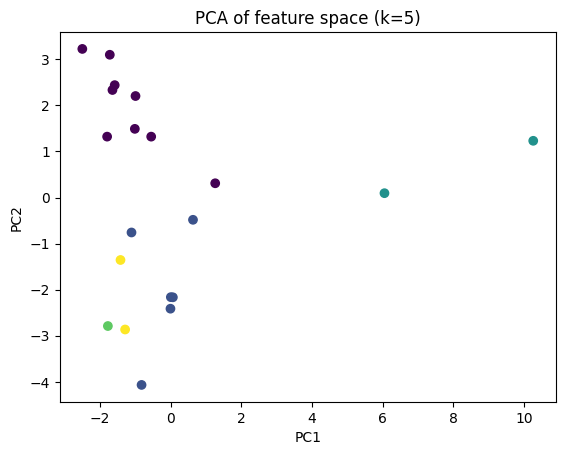

,file,cluster,duration_s,rms,peak,env_dom_freq
8,20220511_110903_077531_001_channel1.bin,0,12.0000,0.199368,1.093623,14.648438
10,20220517_112032_080808_001_channel1.bin,0,9.0000,0.397086,2.853836,2.441406
12,20220517_122558_080808_001_channel1.bin,0,8.0000,0.333443,2.918983,2.441406
11,20220517_120716_058309_001_channel1.bin,0,1.0080,0.883595,5.839401,1.984127
9,20220511_120748_077531_001_channel1.bin,0,10.0000,0.568100,4.058151,1.953125
13,20220517_124824_058309_001_channel1.bin,0,10.0000,0.582558,5.316876,1.953125
16,20220521_121352_079966_001_channel1.bin,0,1.1940,1.439074,9.078464,1.675042
18,20241105_120427_067989_001_channel1.bin,0,1.3555,3.024641,20.639865,1.475470
17,20220521_121722_079966_001_channel1.bin,0,12.0000,1.165163,9.202687,1.464844
3,20220509_094934_031264_001_channel1.bin,1,1.0210,1.779929,20.480243,11.753183


In [9]:
k_best = max(scores, key=scores.get)
print("Best k:", k_best, "silhouette:", scores[k_best])

km = KMeans(n_clusters=k_best, random_state=0, n_init="auto")
df["cluster"] = km.fit_predict(Xs)

pca = PCA(n_components=2, random_state=0)
Z = pca.fit_transform(Xs)
df["pc1"], df["pc2"] = Z[:,0], Z[:,1]

plt.figure()
plt.scatter(df["pc1"], df["pc2"], c=df["cluster"])
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.title(f"PCA of feature space (k={k_best})")
plt.show()

df[["file","cluster","duration_s","rms","peak","env_dom_freq"]].sort_values(["cluster","env_dom_freq"], ascending=[True, False])


## 7) Save outputs

In [10]:
df.to_csv("train_analysis_results.csv", index=False)
print("Saved train_analysis_results.csv")


Saved train_analysis_results.csv


In [11]:
df.head(5)

,date,time,sensor_id,deployment_id,channel,file,n_samples,segment_start,segment_end,duration_s,...,spec_rolloff85,bandpower_5_20,bandpower_20_60,bandpower_60_150,bandpower_150_400,env_dom_freq,env_dom_power,cluster,pc1,pc2
0,20220507,131544,65205,1,1,20220507_131544_065205_001_channel1.bin,16000,0,2416,1.2085,...,332.643773,0.247347,2.351780,14.579481,17.442724,1.654944,3.253158,2,6.049358,0.093596
1,20220507,131853,65205,1,1,20220507_131853_065205_001_channel1.bin,14000,0,2451,1.2260,...,342.577488,0.537990,4.228478,23.536800,63.619162,1.631321,8.326839,2,10.259741,1.230646
2,20220509,091022,31264,1,1,20220509_091022_031264_001_channel1.bin,34000,0,33999,17.0000,...,272.949219,0.001582,0.214654,1.064942,2.009826,1.464844,0.315791,1,-1.110369,-0.759147
3,20220509,094934,31264,1,1,20220509_094934_031264_001_channel1.bin,28000,20471,22512,1.0210,...,301.665034,0.001868,0.302752,1.733093,4.143256,11.753183,0.665652,1,0.003337,-2.162528
4,20220509,095320,31157,1,1,20220509_095320_031157_001_channel1.bin,50000,14758,16950,1.0965,...,176.014592,0.000350,0.044180,0.923580,0.721567,1.823985,0.173392,1,-0.825553,-4.067906
